### The Philosophy of Feature Scaling: Eliminating Data Stereotypes  

The core objective of feature scaling is to strip away what can be termed as the **"structural stereotypes"** of different data ranges. Without scaling, a model is inherently **biased**; it often misinterprets **large numerical differences** as a sign of **higher importance**. This is a form of "metric deception" where the model follows the **magnitude of the numbers**rather than the **actual significance** of the features.  
  
By bringing all features into a unified scale, we establish a neutral starting point where all inputs are **granted equal importance** at the **beginning** of the search process. This forces the model to look past the deceptive scales and truly investigate which **features** are **essential** and **which are not**, without being distracted by the "**louder**" numerical values.

Ultimately, this ensures that the model’s journey toward finding the truth is guided by the **genuine impact** of the information, not by the **accidental scale** of its measurement.  

Some algorithms, such as **Gradient Descent** , which rely on characteristic values for improvement, will be greatly **influenced** by **large** values and **neglect** **small** values regardless of their importance, making approaching optimal values **very costly** or even **impossible**.

---

**Normalization: The Strict Democratic Approach**  

This method adopts a **strict democratic stance**, imposing a **single** "playing field" for all features. Its primary strength lies in maintaining the ratio and proportion between the values of a single feature; this compression does not distort the data's internal distribution but rather enforces a new scale upon it.

**However**, despite its democratic nature, it harbors a fatal flaw in the presence of **outliers**. Because the model **refuses** to ignore these **extreme values**, they inevitably dictate the boundaries. This often results in the rest of the data being suffocated or trapped within an exponentially smaller and less distinguishable range.
$$ x_{norm} = \frac{x-x_{min}}{x_{max}-x_{min}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalization(X):
    """
    paramter :
    X (numpy.ndarray): The input features to be normalized.
    returns :
    X_norm (numpy.ndarray): The normalized input features.

    """
    x_min = np.min(X, axis=0)
    x_max = np.max(X, axis=0)
    X_range = x_max - x_min
    x_norm = (X - x_min) / (X_range + 10e-8)  # to avoid division by zero
    return x_norm

x[0]= 4.17022004702574, x[1]= 7.203244934421581, x[0]/x[1] = 0.5789363106476968
x_norm[0]= 0.4306242120935136, x_norm[1]= 0.7439055863764471, x_norm[0]/x_norm[1] = 0.5788694425472426


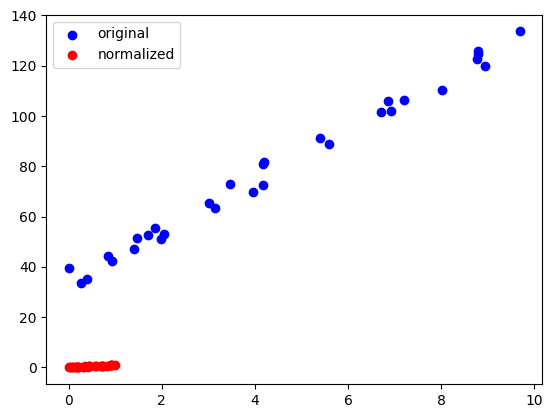

In [3]:
#generate random data 
np.random.seed(1) #for reproducibility
X = np.random.random(30)*10
noise = np.random.random(30)*10 
y = 10*X+30 +noise

X_norm,y_norm=normalization(X),normalization(y) #normalize the data
plt.scatter(X,y,color="blue",label="original")
plt.scatter(X_norm,y_norm ,color="red" ,label="normalized")
plt.legend()
print(f"x[0]= {X[0]}, x[1]= {X[1]}, x[0]/x[1] = {X[0]/X[1]}\nx_norm[0]= {X_norm[0]}, x_norm[1]= {X_norm[1]}, x_norm[0]/x_norm[1] = {X_norm[0]/X_norm[1]}")

It is very clear how normalization compressed the dimensions of the numbers, but it perfectly maintained the ratio and proportion between the numbers.

---

**Standardization :statistical significance** 
Standardization is a robust scaling technique that reframes data based on its **relative position to the mean**, **safeguarding** the **variance** and making features unitless. While it is most powerful with **Gaussian-like distributions**, it ensures that the model focuses on the **signal (statistical importance)** rather than the noise of raw magnitudes, effectively neutralizing the impact of outliers."
$$x_{new}=\frac{x-\mu}{\sigma}$$

In [4]:
def standardization(X):
    """
    parameter :
    X (numpy.ndarray): The input features to be standardized.
    returns :
    X_std (numpy.ndarray): The standardized input features.

    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    x_standardized = (X - mu) / (sigma + 10e-8)  # to avoid division by zero
    return x_standardized

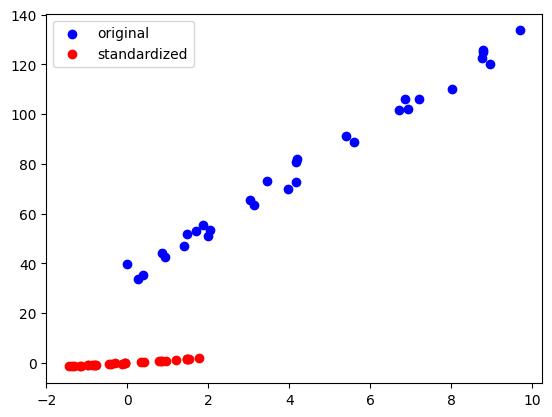

In [5]:
X_std,y_std=standardization(X),standardization(y) #standardize the data
plt.scatter(X,y,color="blue",label="original")
plt.scatter(X_std,y_std ,color="red" ,label="standardized")
plt.legend()

Post-standardization, values are centered **around zero**, even when raw data **lacks negative value**s. This transformation clarifies the **variance** the model **aims** to explain: **negative** values indicate a result **below the mean**, zero represents the **equilibrium point**, and **positive** values signify those **above average**. Consequently, values are interpreted not merely as **magnitudes**, but as **distributional significance**, providing **directional cues** that streamline **weight** updates during **optimization**.